# Word Vectors and spaCY

* spaCy ML models have word vectors stored in them.

In [7]:
import spacy
import numpy as np

In [3]:
# !python -m spacy download en_core_web_md

# Word Vectors

* Word Vectors = word embeddings, or numerical representations of words in multidimensional space through matrices.

* Used by computer systems to understand what a word actually means.
  - Uses an array of a complex sequence of floating numbers.

  - This array provides computer SYNTATICAL and SEMANTICAL meaning.

* Method(old-school word2vec approach):
  - Give computer system text.

  - It reads text and figures out how words are used in RELATION to other words.

  - Through this training, it figures out meaning, and understands how a word may relate to other words within a sentence or language.

In [4]:
# Larger model with word vectors.
nlp = spacy.load("en_core_web_md")

In [5]:
with open("data/wiki_us.txt", "r") as f:
  text = f.read()

In [6]:
doc = nlp(text)
sentence1 = list(doc.sents)[0]
print(sentence1)

The United States of America (U.S.A. or USA), commonly known as the United States (U.S. or US) or America, is a country primarily located in North America.


In [12]:
# How similar is the word "country" to other words within our model's word embeddings? Syntactially these words are used in similar situations as "country".
your_word = "country"

ms = nlp.vocab.vectors.most_similar(
    np.asarray([nlp.vocab.vectors[nlp.vocab.strings[your_word]]]), n=10)
words = [nlp.vocab.strings[w] for w in ms[0][0]]
distances = ms[2]
print(words)

['anti-poverty', 'inner-city', 'SLUMS', 'Divides', 'INTERSECT', 'Socioeconomic', 'drop-out', 'dropout', 'handicaps', 'south-east']


In [17]:
# How similar are these 2 different sentences?
doc1 = nlp("I like salty fries and hamburgers.")
doc2 = nlp("Fast food tastes very good.")

In [21]:
# spaCy is going into its WORD EMBEDDINGS and looking at the clusters, to determine the similarity score(assigning a prediction).
print(doc1, "<->", doc2, doc1.similarity(doc2))

I like salty fries and hamburgers. <-> Fast food tastes very good. 0.8015959858894348


In [22]:
doc3 = nlp("The Empire State Building is in New York.")

In [23]:
print (doc1, "<->", doc3, doc1.similarity(doc3))

I like salty fries and hamburgers. <-> The Empire State Building is in New York. 0.5638526678085327


In [24]:
doc4 = nlp("I enjoy oranges.")
doc5 = nlp("I enjoy apples.")

In [28]:
# Apples and oranges are in a similar cluster, of "fruit" probably.
print(doc4, "<->", doc5, doc4.similarity(doc5))

I enjoy oranges. <-> I enjoy apples. 0.9522808194160461


In [26]:
doc6 = nlp("I enjoy burgers.")

In [29]:
# Apples and oranges are in a similar cluster, of "fruit" probably. Whereas "burger" is a bit more different from the fruit, hence the lower score.
print(doc4, "<->", doc6, doc4.similarity(doc6))

I enjoy oranges. <-> I enjoy burgers. 0.8937572240829468


In [30]:
# Calculate the difference between "salty fries" and "hamburgers".
french_fries = doc1[2:4]
burgers = doc1[5]
print(french_fries, "<->", burgers, french_fries.similarity(burgers))

salty fries <-> hamburgers 0.5733411312103271


In [32]:
apple = nlp("apple")
orange = nlp("orange")
print(apple, "<->", orange, apple.similarity(orange))

apple <-> orange 0.5900056958198547


In [33]:
banana = nlp("banana")
print(apple, "<->", banana, apple.similarity(banana))

apple <-> banana 1.0


# SpaCy Pipelines

* Sample spaCy pipeline can perform some kind of action on a piece of data.

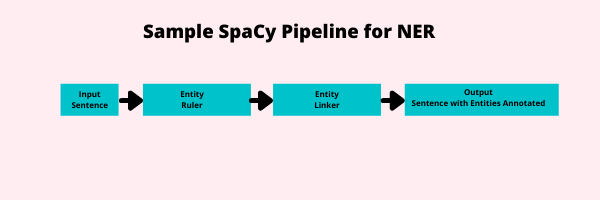

In [34]:
# Make a blank model pipeline.
nlp = spacy.blank("en")

In [35]:
# Add a pipeline sentencizer
nlp.add_pipe("sentencizer")

In [36]:
nlp.analyze_pipes()

{'summary': {'sentencizer': {'assigns': ['token.is_sent_start', 'doc.sents'],
   'requires': [],
   'scores': ['sents_f', 'sents_p', 'sents_r'],
   'retokenizes': False}},
 'problems': {'sentencizer': []},
 'attrs': {'token.is_sent_start': {'assigns': ['sentencizer'], 'requires': []},
  'doc.sents': {'assigns': ['sentencizer'], 'requires': []}}}

In [37]:
nlp2 = spacy.load("en_core_web_sm")

In [38]:
nlp2.analyze_pipes()

{'summary': {'tok2vec': {'assigns': ['doc.tensor'],
   'requires': [],
   'scores': [],
   'retokenizes': False},
  'tagger': {'assigns': ['token.tag'],
   'requires': [],
   'scores': ['tag_acc',
    'pos_acc',
    'tag_micro_p',
    'tag_micro_r',
    'tag_micro_f'],
   'retokenizes': False},
  'parser': {'assigns': ['token.dep',
    'token.head',
    'token.is_sent_start',
    'doc.sents'],
   'requires': [],
   'scores': ['dep_uas',
    'dep_las',
    'dep_las_per_type',
    'sents_p',
    'sents_r',
    'sents_f'],
   'retokenizes': False},
  'attribute_ruler': {'assigns': [],
   'requires': [],
   'scores': [],
   'retokenizes': False},
  'lemmatizer': {'assigns': ['token.lemma'],
   'requires': [],
   'scores': ['lemma_acc'],
   'retokenizes': False},
  'ner': {'assigns': ['doc.ents', 'token.ent_iob', 'token.ent_type'],
   'requires': [],
   'scores': ['ents_f', 'ents_p', 'ents_r', 'ents_per_type'],
   'retokenizes': False}},
 'problems': {'tok2vec': [],
  'tagger': [],
  'parse